In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [2]:
DATA_PROCESSED = Path('../data/processed')
deals = pd.read_parquet(DATA_PROCESSED / 'deals_clean.parquet')

In [3]:
print(deals.shape)
print(deals.dtypes)

(21593, 26)
Id                                 str
Deal Owner Name                    str
Closing Date            datetime64[us]
Quality                            str
Stage                              str
Lost Reason                        str
Page                               str
Campaign                           str
SLA                    timedelta64[us]
Content                            str
Term                               str
Source                             str
Payment Type                       str
Product                            str
Education Type                     str
Created Time            datetime64[us]
Course duration                float64
Months of study                float64
Initial Amount Paid            float64
Offer Total Amount             float64
Contact Name                       str
City                               str
Level of Deutsch                   str
Stage_Group                        str
is_duplicate_lead                 bool
is_outlier_co

# 05. Описательная статистика — Deals

**Цель:** получить общую картину распределения числовых и категориальных полей датасета Deals. Зафиксировать ключевые наблюдения для отчёта.

**Структура:**
1. Числовые поля — describe, мода, выбросы, визуализация распределений
2. Категориальные поля — частоты, доли, визуализация
3. Сводные выводы для отчёта

In [5]:
numeric_cols = ['Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount']
deals[numeric_cols].describe().round(2)

,Course duration,Months of study,Initial Amount Paid,Offer Total Amount
count,3587.00,840.00,4165.00,4185.00
mean,10.20,5.44,950.09,7128.72
std,1.83,2.92,1422.15,4636.02
min,6.00,0.00,0.00,0.00
25%,11.00,3.00,300.00,3000.00
50%,11.00,5.00,1000.00,11000.00
75%,11.00,8.00,1000.00,11000.00
max,11.00,11.00,11500.00,11500.00


In [6]:
print("Мода (самое частое значение):")
for col in numeric_cols:
    mode_val = deals[col].mode().iloc[0]  # mode() возвращает Series — берём первое
    count = (deals[col] == mode_val).sum()
    print(f"  {col}: {mode_val} (встречается {count} раз)")

Мода (самое частое значение):
  Course duration: 11.0 (встречается 3012 раз)
  Months of study: 6.0 (встречается 107 раз)
  Initial Amount Paid: 1000.0 (встречается 2623 раз)
  Offer Total Amount: 11000.0 (встречается 1860 раз)


In [7]:
deals['SLA_hours'] = deals['SLA'].dt.total_seconds() / 3600
print(deals['SLA_hours'].describe().round(2))

count    15533.00
mean        32.17
std        204.79
min          0.00
25%          1.22
50%          5.53
75%         15.64
max       7474.57
Name: SLA_hours, dtype: float64


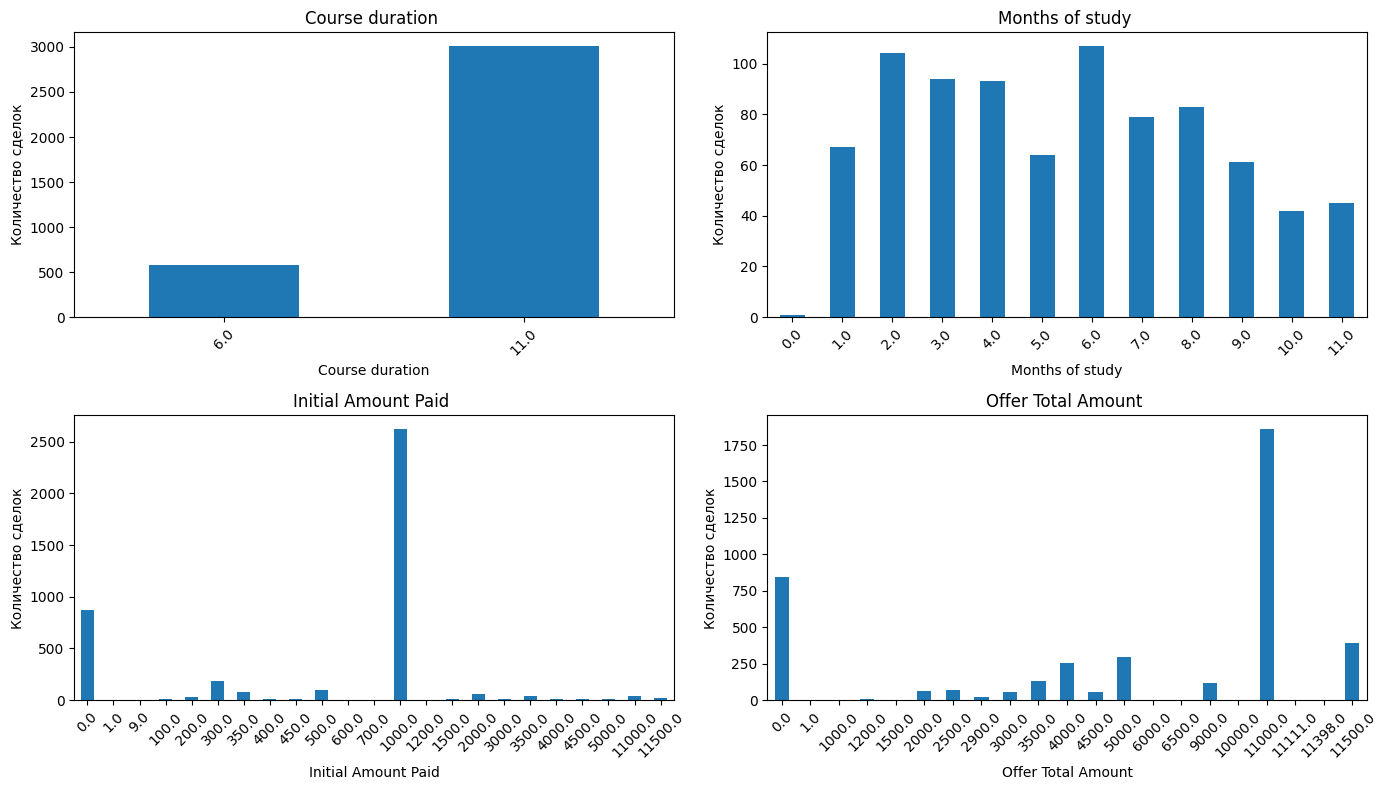

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    top_values = deals[col].value_counts().sort_index()
    top_values.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество сделок')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Выводы из данных 

- **Course duration**: мы видим по графикам, что есть курсы 6 и 11 месяцев. Наиболее часто люди покупают курс на 11 месяцев. 

- **Months of study**: это те люди которые активно на данный момент учатся, то есть показывает распределение сколько сейчас учеников на каждом месяце обучения. Снижение количества учеников на 9-11 месяцах обучения может объясняться двумя версиями: либо отсевом, либо тем, что объём продаж был ниже год назад относительно текущего момента. Проверим потом при сопоставлении  с тенденцией создания сделок по месяцам. Но в целом из этого графика можно сказать что каждый месяц в школе занимаются в среднем больше 60 учеников.

- **Initial Amount Paid**: это то, сколько клиентов заплатили первым платежом - может быть вся сумма, может быть часть. Видим, что в основном люди платят 1000 евро первым платежом. Следущая по частоте оплат - 300 евро. МНого 0, но как это интерпретировать - то ли пробный курс - то ли на стадии подписания договора, но оплата еще в любом случает не дошла. 


- **Offer Total Amount**: полная стоимость обучения по договору - сколько клиент заплатит когда доучится. Самое частое значение 11000 евро, максимум 11500, минимум 0 - вероятно это пробное обучение, либо артефакты. 

- **SLA**: - время ответа продажника. время с того момента как лид отправил заявку и менеджер связался. В среднем 32 часа (что-то много - полтора суток), максимум 7474 сама - 311 суток - похоже на выброс или аномалию. Минимум 0 часов - то есть почти мгновенно. 


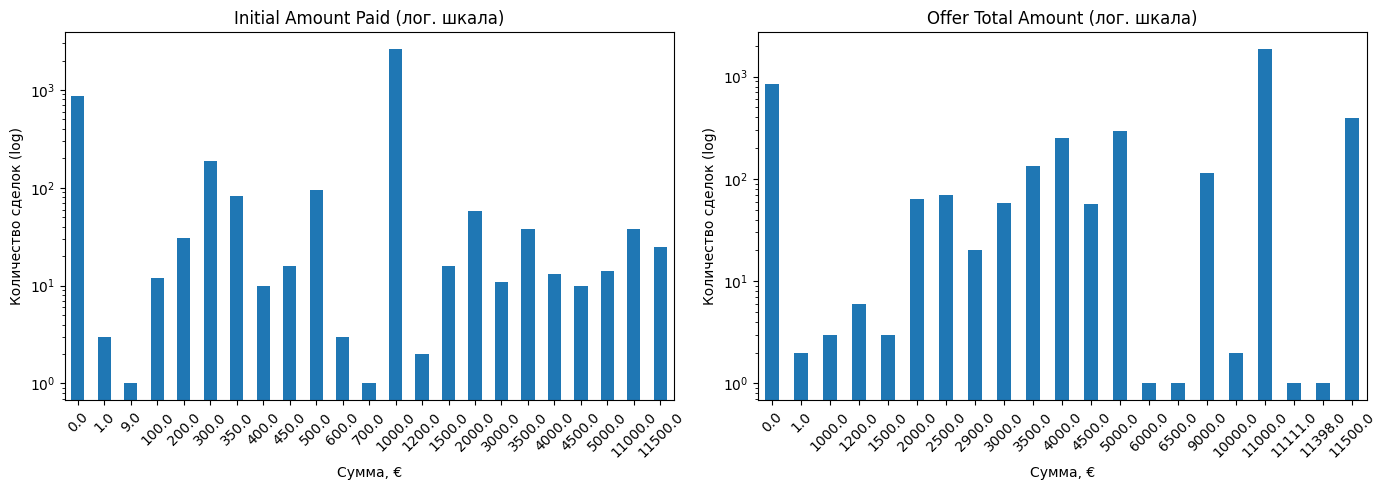

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Initial Amount Paid с log scale
top_initial = deals['Initial Amount Paid'].value_counts().sort_index()
top_initial.plot(kind='bar', ax=axes[0])
axes[0].set_title('Initial Amount Paid (лог. шкала)')
axes[0].set_yscale('log')  # ВОТ ЭТО — лог-шкала
axes[0].set_xlabel('Сумма, €')
axes[0].set_ylabel('Количество сделок (log)')
axes[0].tick_params(axis='x', rotation=45)

# Offer Total Amount с log scale
top_offer = deals['Offer Total Amount'].value_counts().sort_index()
top_offer.plot(kind='bar', ax=axes[1])
axes[1].set_title('Offer Total Amount (лог. шкала)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Сумма, €')
axes[1].set_ylabel('Количество сделок (log)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
deals[deals['Course duration'].notna()].groupby('Product')['Course duration'].agg(['mean', 'median', 'count'])

,mean,median,count
Product,,,
Digital Marketing,11.0,11.0,1990
UX/UI Design,11.0,11.0,1022
Web Developer,6.0,6.0,575
